In [2]:

# Importing the libraries for data handling, visualization, model building, and evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Loading the heart disease dataset from CSV file
dataset_path = "heart_disease_combined.csv"  

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)
# Show first five rows of dataset
df.head()

Dataset loaded successfully!
Dataset Shape: (920, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


In [4]:
# Displaying all column names in the dataset
print("Dataset Columns:")
print(df.columns)

# Displaying dataset information such as data type and non-null count
print("\nDataset Info:")
print(df.info())

# Checking missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

# Displaying statistical summary of numeric columns
print("\nStatistical Summary:")
print(df.describe())

Dataset Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'source'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  target    920 non-null    int64  
 14  source    920 non-null    object 
dtypes: float64(13), int64(1), 

In [5]:
# Showing available columns so the user can choose the target column
print("Available Columns:")
for col in df.columns:
    print(col)

# Taking target column name from use
target_column = input("\nEnter the target column name: ")

if target_column not in df.columns:
    raise ValueError("Target column not found in dataset.")

print("Selected Target Column:", target_column)

Available Columns:
age
sex
cp
trestbps
chol
fbs
restecg
thalach
exang
oldpeak
slope
ca
thal
target
source



Enter the target column name:  target


Selected Target Column: target


In [6]:
#Filling missing values in categorical columns with mode
# Filling missing values in numeric columns with median

for column in df.columns:
    if df[column].dtype == "object":
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:
        df[column].fillna(df[column].median(), inplace=True)

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
source      0
dtype: int64


In [7]:

# Importing LabelEncoder for converting categorical values into numeric form
from sklearn.preprocessing import LabelEncoder


label_encoders = {}

for column in df.columns:
    if df[column].dtype == "object":
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

print("Categorical columns encoded successfully.")

# Showingencoded dataset
df.head()

Categorical columns encoded successfully.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [8]:
# Displaying the original-to-encoded mapping for target column if it was categorical
if target_column in label_encoders:
    print("Target class mapping:")

    for original, encoded in zip(
        label_encoders[target_column].classes_,
        label_encoders[target_column].transform(label_encoders[target_column].classes_)
    ):
        print(original, "=", encoded)
else:
    print("Target column is already numeric.")

Target column is already numeric.


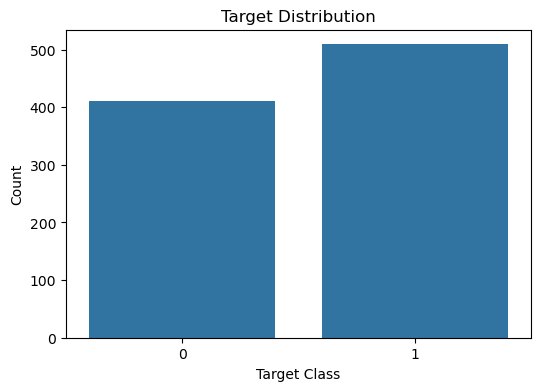

In [9]:
# Plot count of each target class
plt.figure(figsize=(6, 4))
sns.countplot(x=df[target_column])
plt.title("Target Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()

In [10]:
# Selecting numeric feature columns except the target column
numeric_features = df.drop(target_column, axis=1).select_dtypes(include=[np.number]).columns.tolist()

print("Numeric Features:")
print(numeric_features)
# Stop execution if no numeric features are available
if len(numeric_features) == 0:
    raise ValueError("No numeric features found for training.")

Numeric Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'source']


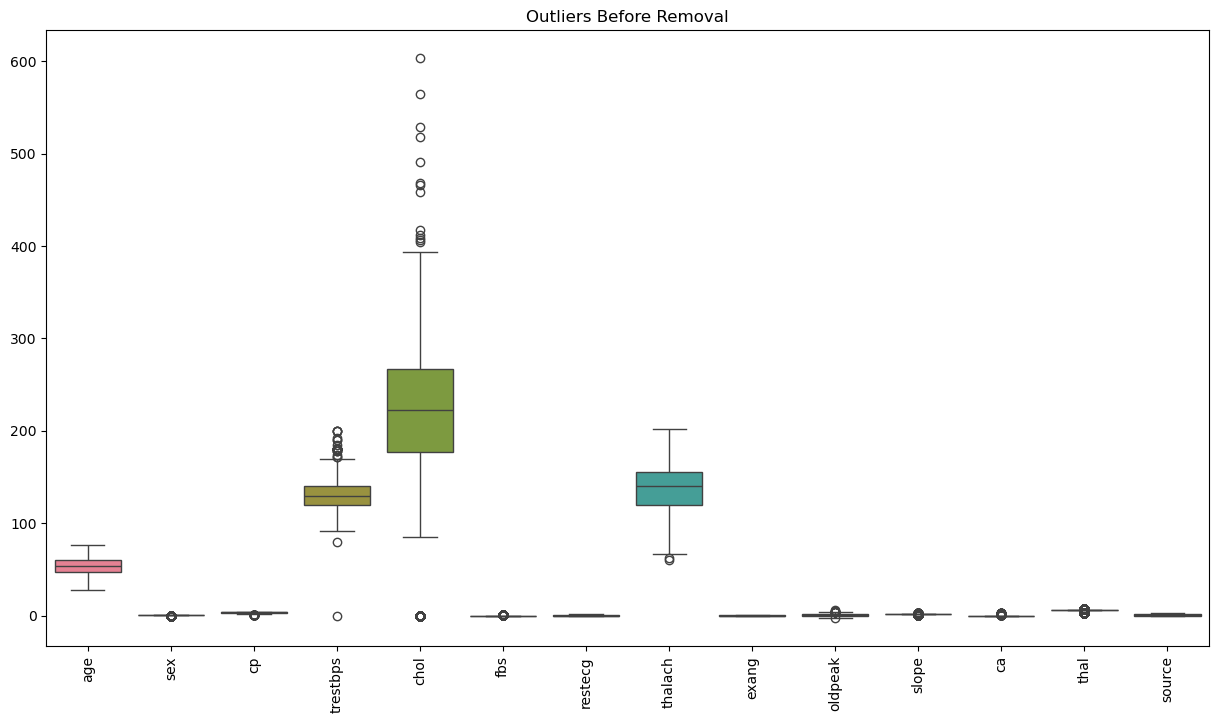

In [11]:
# Displaying boxplot to observe outliers before removal
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_features])
plt.xticks(rotation=90)
plt.title("Outliers Before Removal")
plt.show()

In [14]:
df_cleaned = df.copy()

if "source" in df_cleaned.columns:
    df_cleaned = df_cleaned.drop("source", axis=1)

In [15]:
df_cleaned = df.copy()

# Removing outliers from numeric columns using IQR method
for column in numeric_features:
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_cleaned = df_cleaned[
        (df_cleaned[column] >= lower_limit) &
        (df_cleaned[column] <= upper_limit)
    ]
    
# Comparing dataset shape before and after outlier removal
print("Original Dataset Shape:", df.shape)
print("Dataset Shape After Outlier Removal:", df_cleaned.shape)

Original Dataset Shape: (920, 15)
Dataset Shape After Outlier Removal: (227, 15)


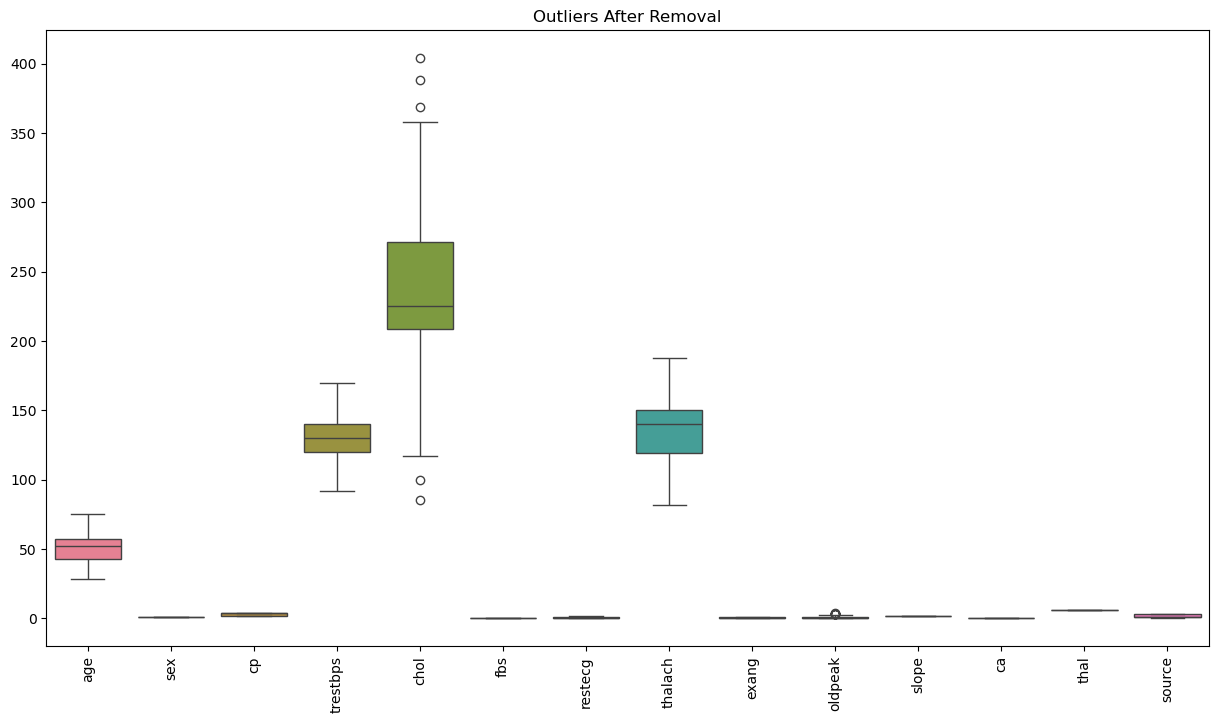

In [16]:
# Displaying boxplot after outlier removal
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_cleaned[numeric_features])
plt.xticks(rotation=90)
plt.title("Outliers After Removal")
plt.show()

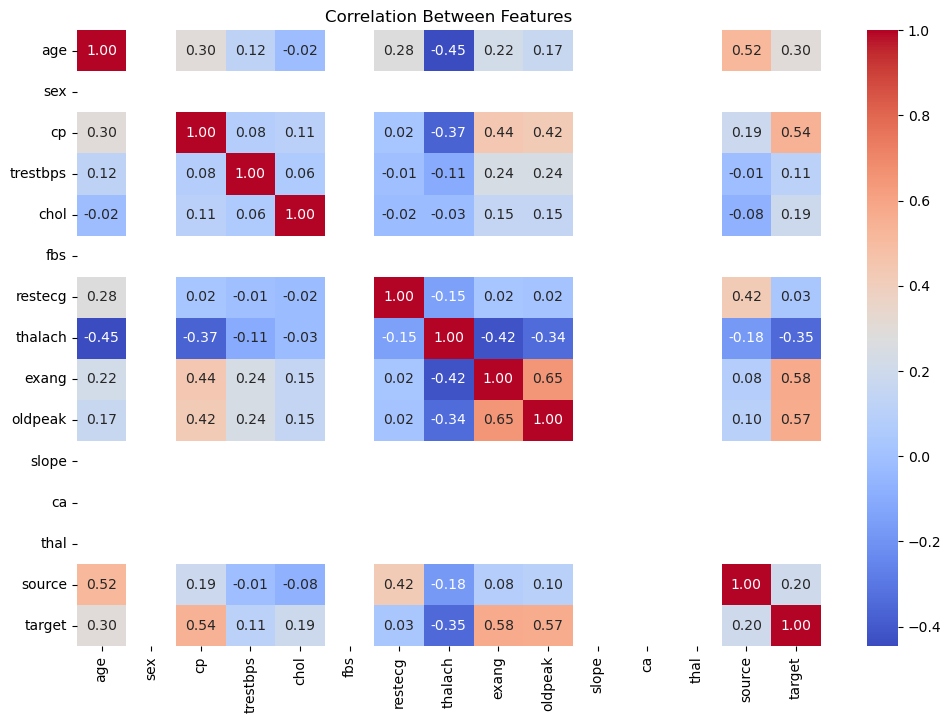

In [17]:
# Ploting correlation heatmap between features and target
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_cleaned[numeric_features + [target_column]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Features")
plt.show()

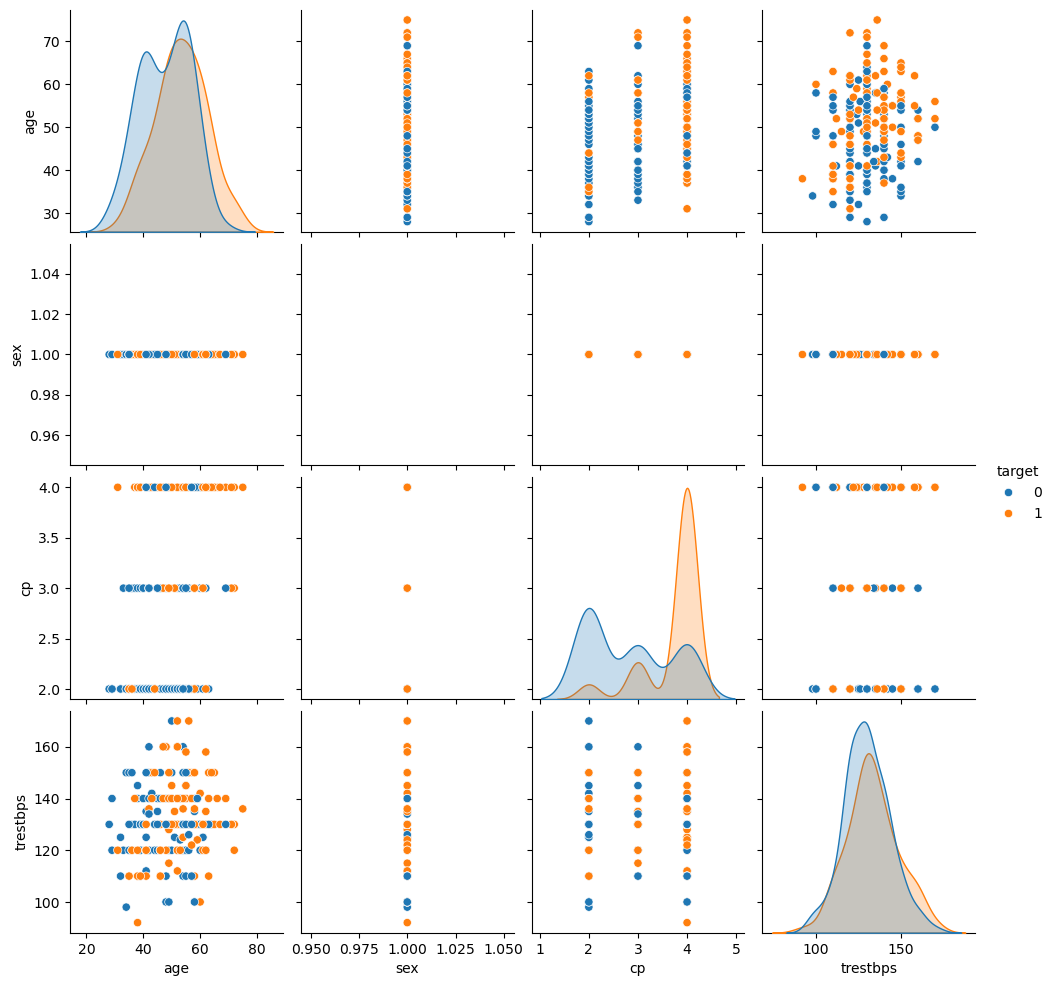

In [18]:
# Selecting first four numeric features and target column for pairplot
selected_features = numeric_features[:4] + [target_column]

# Ploting pairwise relationship between selected features
sns.pairplot(df_cleaned[selected_features], hue=target_column)
plt.show()

In [19]:
# Separating input features and target variable
X = df_cleaned.drop(target_column, axis=1)
y = df_cleaned[target_column]

# Spliting dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (181, 14)
Testing Data Shape: (46, 14)


In [20]:
# Standardizing features for scale-sensitive models
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Training Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Predicting class and probability
log_pred = log_model.predict(X_test_scaled)

log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [22]:
# Training Support Vector Machine model
svm_model = SVC(probability=True)
svm_model.fit(X_train_scaled, y_train)

# Predicting class and probability
svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

In [23]:
# Training Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predicting class and probability
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [24]:
# Training K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predicting class and probability
knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

In [25]:
# Training Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Predicting class and probability
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

In [26]:
# Defining a function to evaluate model performance
def evaluate_model(model_name, y_test, y_pred, y_prob):
    print("\nModel:", model_name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall:", recall_score(y_test, y_pred, average="weighted"))
    print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

    if len(np.unique(y_test)) == 2:
        print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [27]:
# Evaluation of all trained models
evaluate_model("Logistic Regression", y_test, log_pred, log_prob)
evaluate_model("SVM", y_test, svm_pred, svm_prob)
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
evaluate_model("K-Nearest Neighbors", y_test, knn_pred, knn_prob)
evaluate_model("Gradient Boosting", y_test, gb_pred, gb_prob)


Model: Logistic Regression
Accuracy: 0.7608695652173914
Precision: 0.7609109730848861
Recall: 0.7608695652173914
F1 Score: 0.7605290852438044
ROC-AUC Score: 0.8371212121212122

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.78        24
           1       0.76      0.73      0.74        22

    accuracy                           0.76        46
   macro avg       0.76      0.76      0.76        46
weighted avg       0.76      0.76      0.76        46


Model: SVM
Accuracy: 0.782608695652174
Precision: 0.782608695652174
Recall: 0.782608695652174
F1 Score: 0.782608695652174
ROC-AUC Score: 0.8409090909090909

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        24
           1       0.77      0.77      0.77        22

    accuracy                           0.78        46
   macro avg       0.78      0.78      0.78        46
weighted avg       

In [28]:
# Creating a model comparison table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "K-Nearest Neighbors",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred, average="weighted"),
        precision_score(y_test, svm_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted"),
        precision_score(y_test, knn_pred, average="weighted"),
        precision_score(y_test, gb_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, log_pred, average="weighted"),
        recall_score(y_test, svm_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted"),
        recall_score(y_test, knn_pred, average="weighted"),
        recall_score(y_test, gb_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, log_pred, average="weighted"),
        f1_score(y_test, svm_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, knn_pred, average="weighted"),
        f1_score(y_test, gb_pred, average="weighted")
    ]
})
# Add ROC-AUC score if classification is binary
if len(np.unique(y_test)) == 2:
    results["ROC-AUC"] = [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, svm_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, knn_prob),
        roc_auc_score(y_test, gb_prob)
    ]
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.760870,0.760911,0.760870,0.760529,0.837121
1,SVM,0.782609,0.782609,0.782609,0.782609,0.840909
2,Random Forest,0.760870,0.761815,0.760870,0.760983,0.822917
3,K-Nearest Neighbors,0.739130,0.739130,0.739130,0.739130,0.833333
4,Gradient Boosting,0.739130,0.741930,0.739130,0.739130,0.825758


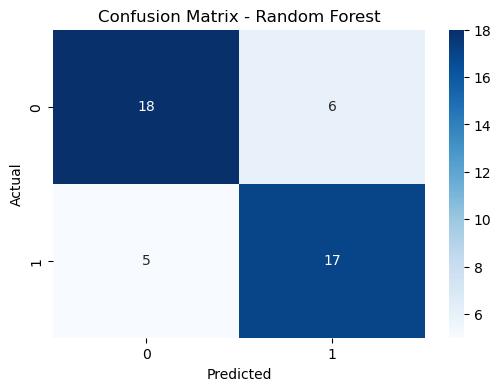

In [29]:
# Creating confusion matrix for Random Forest model
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

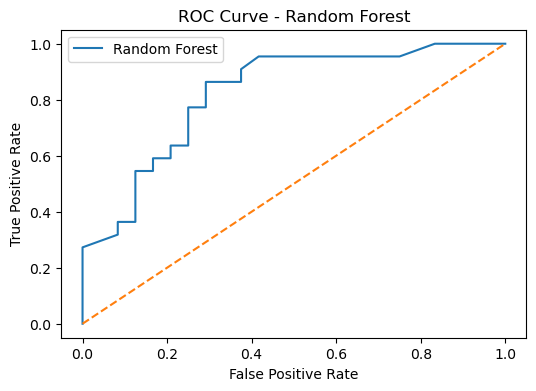

In [30]:

# Ploting ROC curve for Random Forest if target has two classes
if len(np.unique(y_test)) == 2:
if len(np.unique(y_test)) == 2:
    fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label="Random Forest")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Random Forest")
    plt.legend()
    plt.show()

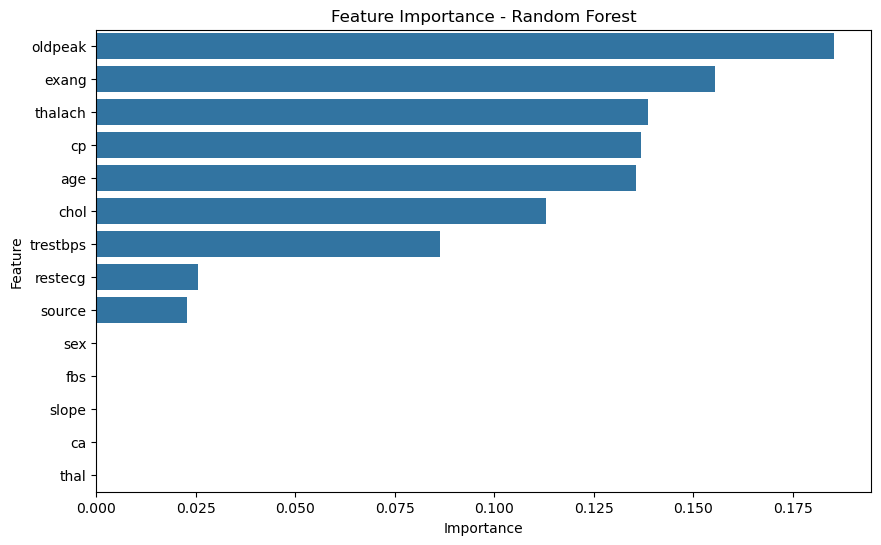

,Feature,Importance
9,oldpeak,0.185485
8,exang,0.155406
7,thalach,0.138747
2,cp,0.136856
0,age,0.135574
4,chol,0.113032
3,trestbps,0.086444
6,restecg,0.025672
13,source,0.022784
1,sex,0.000000


In [31]:
# Calculating feature importance from Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Ploting feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance - Random Forest")
plt.show()

feature_importance

In [33]:
# Asking the user to enter patient details for prediction
print("Enter patient details for disease prediction")
print("Enter values for each feature shown below.\n")

user_values = []

for feature in X.columns:
    value = float(input(f"Enter value for {feature}: "))
    user_values.append(value)

user_patient = pd.DataFrame([user_values], columns=X.columns)

print("\nUser Entered Patient Data:")
user_patient

Enter patient details for disease prediction
Enter values for each feature shown below.



Enter value for age:  55
Enter value for sex:  1
Enter value for cp:  0
Enter value for trestbps:  140
Enter value for chol:  250
Enter value for fbs:  0
Enter value for restecg:  1
Enter value for thalach:  150
Enter value for exang:  0
Enter value for oldpeak:  1.5
Enter value for slope:  1
Enter value for ca:  0
Enter value for thal:  2
Enter value for source:  2



User Entered Patient Data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source
0,55.0,1.0,0.0,140.0,250.0,0.0,1.0,150.0,0.0,1.5,1.0,0.0,2.0,2.0


In [34]:
# Predicting disease class for entered patient data
prediction = rf_model.predict(user_patient)

print("Predicted Class:", prediction[0])

# Displaying final prediction result
if prediction[0] == 1:
    print("Final Result: Heart Disease Detected")
else:
    print("Final Result: No Heart Disease Detected")

Predicted Class: 0
Final Result: No Heart Disease Detected
